# IBM HR Analytics: Employee Attrition & Performance
#### Author: Nida | Beginner Level | Tool: Python

This project analyzes IBM's fictional HR dataset to uncover key insights about employee attrition.

# Importing libraries

In [4]:
import pandas as pd

In [5]:
import numpy as np

In [6]:
import matplotlib.pyplot as plt


In [7]:
import seaborn as sns

In [8]:
import warnings

In [9]:
warnings.filterwarnings("ignore")

#Importing datasets

In [10]:
from google.colab import files
uploaded= files.upload()

Saving IBM_DATASET_INTERNSHIP.csv to IBM_DATASET_INTERNSHIP.csv


In [11]:
df=pd.read_csv("IBM_DATASET_INTERNSHIP.csv")

In [12]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


#UNDERSTANDING THE DATA

In [13]:
# Checking basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [14]:
# Checking rows and columns
print("Rows:",df.shape[0])
print("Columns:",df.shape[1])

Rows: 1470
Columns: 35


In [15]:
#checking missing values
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [16]:
# checking duplicate values
df.duplicated().sum()

np.int64(0)

### EDA

In [17]:
# checking stats like mean,min,max,etc..
# This gives us average age, income, etc
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [18]:
# Average Tenure
print("Average Years at Company:", df['YearsAtCompany'].mean())

Average Years at Company: 7.0081632653061225


*Insight: Employees stay around 7 years.*

#ANALYZING THE TARGET VARIABLE ~ ATTRITION .

In [19]:
df['Attrition'].value_counts(normalize=True)*100

,proportion
Attrition,
No,83.877551
Yes,16.122449


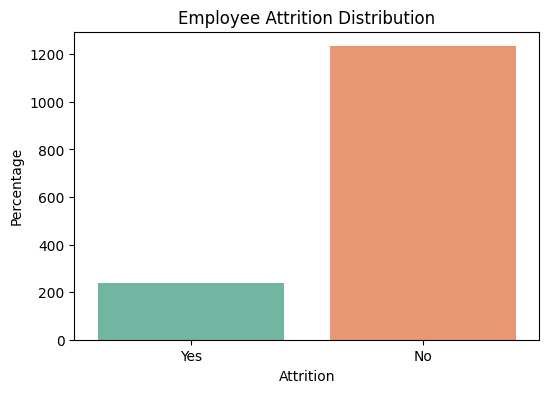

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(x='Attrition',data=df, palette='Set2')
plt.title('Employee Attrition Distribution')
plt.xlabel('Attrition')
plt.ylabel('Percentage')
plt.show()

*Insight: Around 16% of employees have left*

**Demographics Analysis:**
To explore employee age, gender, and departments.

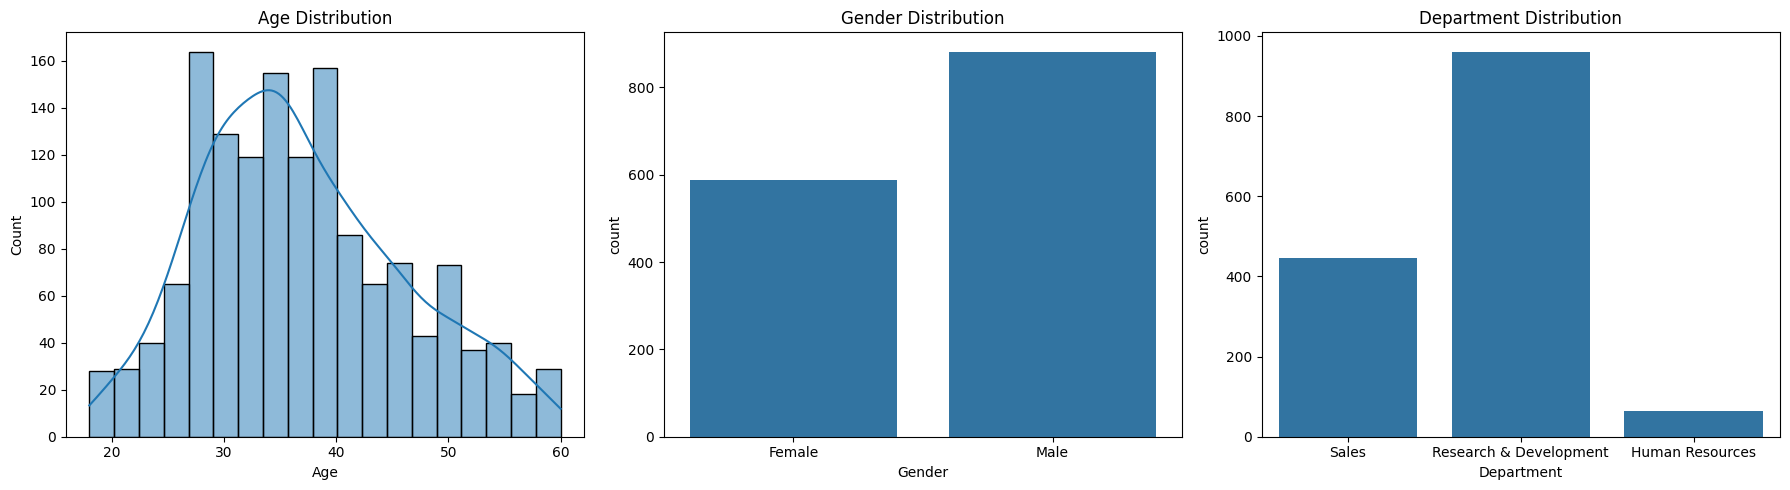

In [21]:
figs, plt.axes= plt.subplots(1,3,figsize=(18,5))
sns.histplot(data=df, x='Age', kde=True, ax=plt.axes[0])
plt.axes[0].set_title("Age Distribution")
sns.countplot(data=df, x='Gender', ax=plt.axes[1])
plt.axes[1].set_title("Gender Distribution")
sns.countplot(data=df, x='Department', ax=plt.axes[2])
plt.axes[2].set_title("Department Distribution")
plt.tight_layout()
plt.show()

*INSIGHT: Most employees are aged 30–35, majority male, and mainly in R&D.*

#**Attrition by Categorical Columns**

To check if job role, income, overtime, etc., affect attrition.

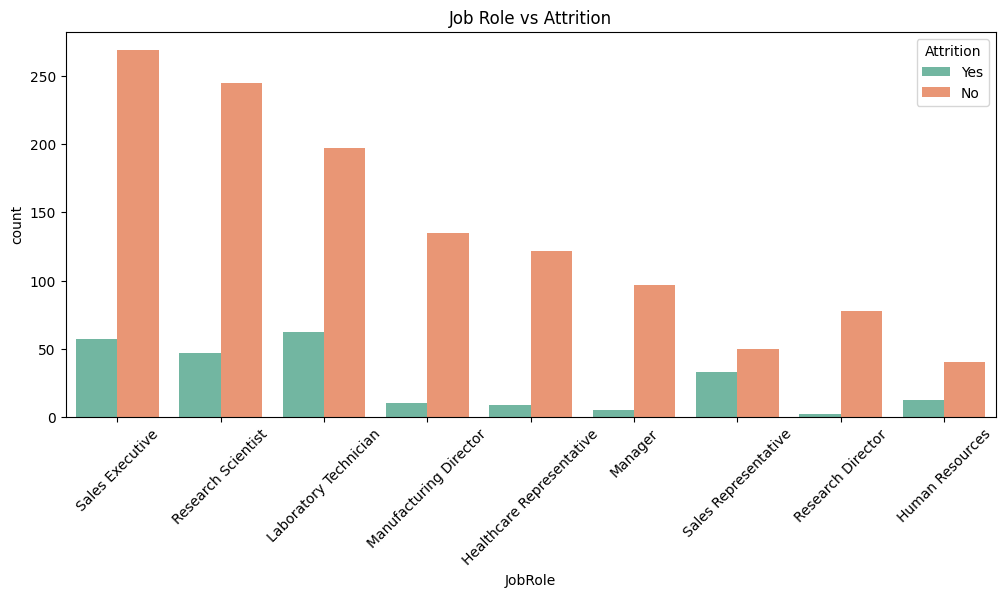

In [53]:
plt.figure(figsize=(12,5))
sns.countplot(data=df, x='JobRole', hue='Attrition', palette='Set2')
plt.xticks(rotation=45)
plt.title('Job Role vs Attrition')
plt.show()


*INSIGHT: Attrition is higher in roles like Sales Representative and Laboratory Technician, while roles such as Research Director and Healthcare Representative have much lower attrition*

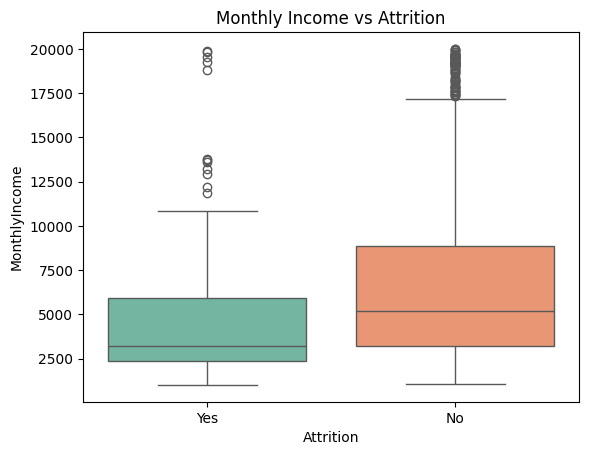

In [51]:
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', palette='Set2')
plt.title('Monthly Income vs Attrition')
plt.show()

*INSIGHT:Employees with lower monthly income are significantly more likely to leave the company than those with higher income.*

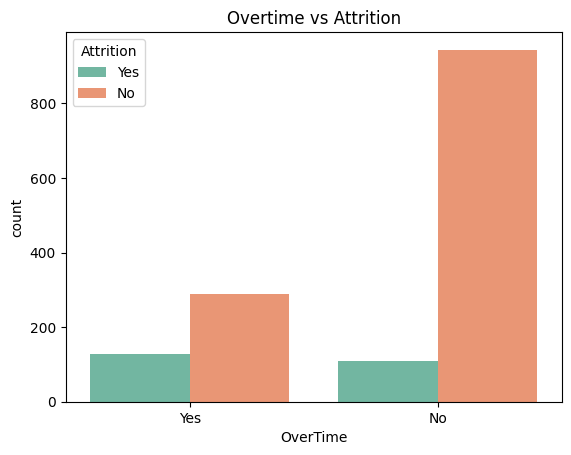

In [54]:
sns.countplot(data=df, x='OverTime', hue='Attrition', palette='Set2')
plt.title('Overtime vs Attrition')
plt.show()

*INSIGHT: Employees who work overtime are significantly more likely to leave the company than those who do not.*

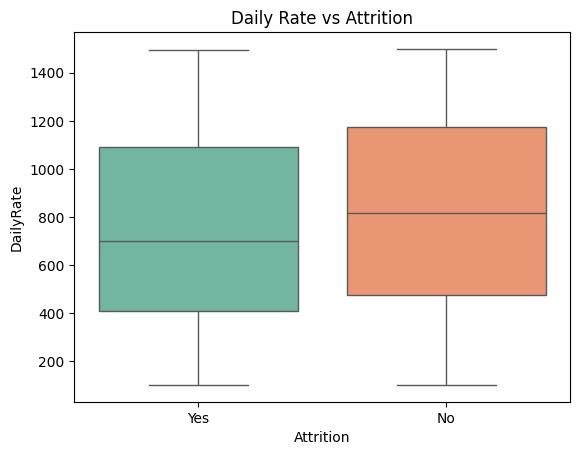

In [52]:
sns.boxplot(data=df, x='Attrition', y='DailyRate', palette='Set2')
plt.title('Daily Rate vs Attrition')
plt.show()

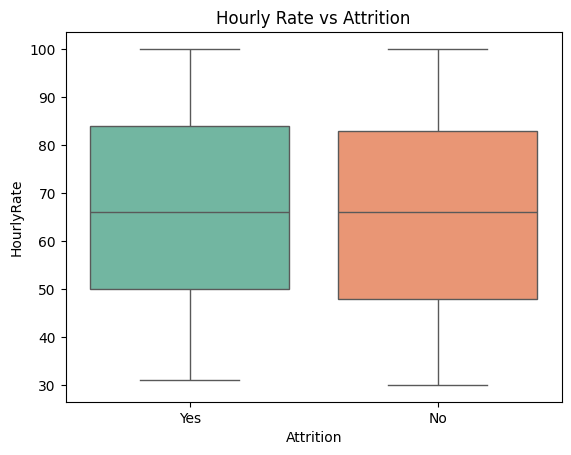

In [55]:
sns.boxplot(data=df, x='Attrition', y='HourlyRate', palette='Set2')
plt.title('Hourly Rate vs Attrition')
plt.show()

*INSIGHT: From plot we have seen that there is no significant difference in the hourly rate and attrition. Therefore hourly rate is considered as not signifcant to attrition*

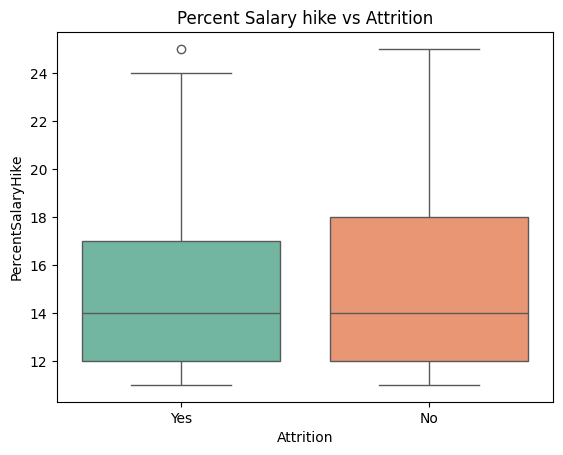

In [60]:
sns.boxplot(data=df, x='Attrition', y='PercentSalaryHike', palette='Set2')
plt.title('Percent Salary hike vs Attrition')
plt.show()

*INSIGHT:Majority (60% of total strength) of employee's receive 16% salary hike in the company, employee's who received less salary hike have left the company.*

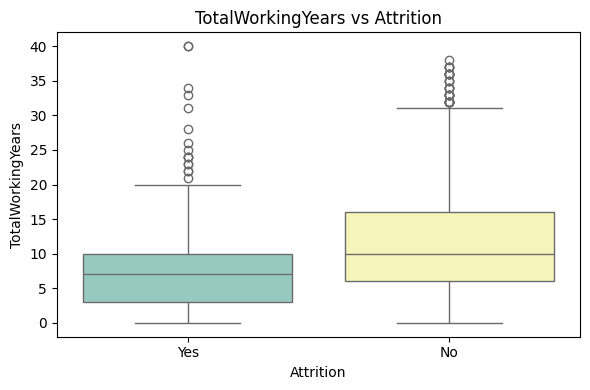

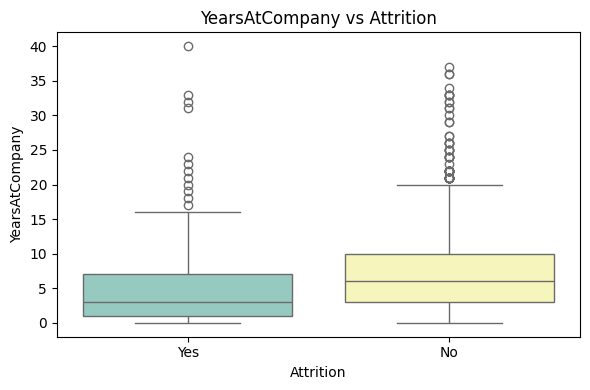

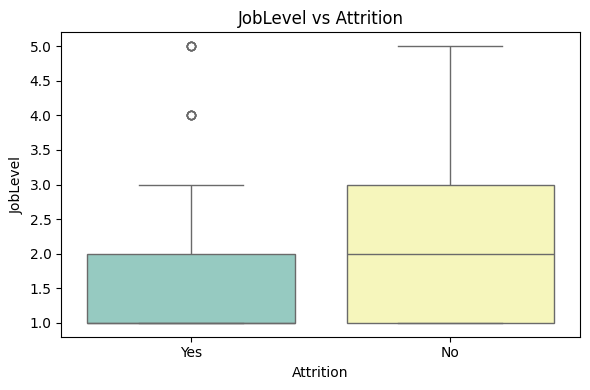

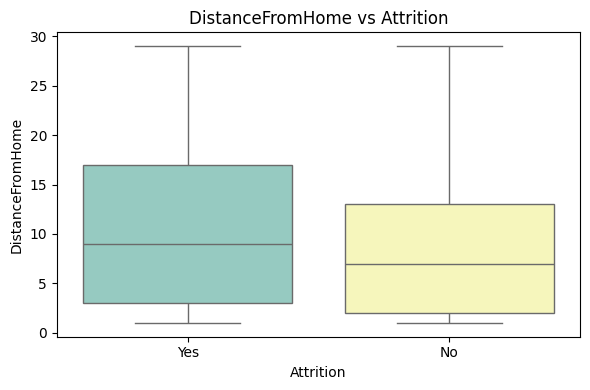

In [62]:
# List of numeric features to analyze against Attrition
num_features = ['TotalWorkingYears', 'YearsAtCompany',
                'JobLevel', 'DistanceFromHome']

for col in num_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x='Attrition', y=col, palette='Set3')
    plt.title(f'{col} vs Attrition')
    plt.tight_layout()
    plt.show()


*INSIGHT:*


*   *TotalWorkingYears:	People with fewer total working years show higher attrition.*
*   *YearsAtCompany:	Those who recently joined the company have a higher chance of leaving.*


*   *JobLevel:	Employees at lower job levels tend to leave more often.*
*   *DistanceFromHome:	Employees living farther from work show slightly higher attrition.*





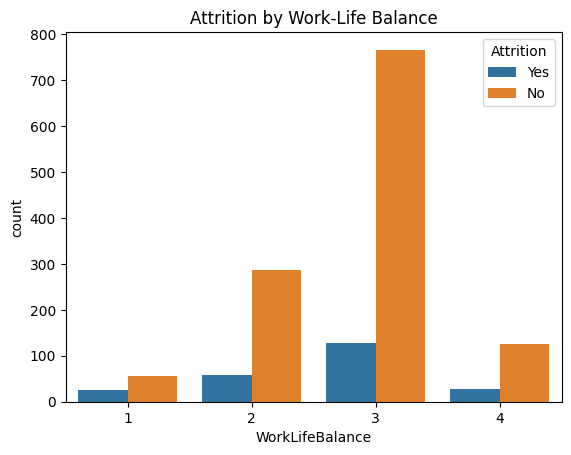

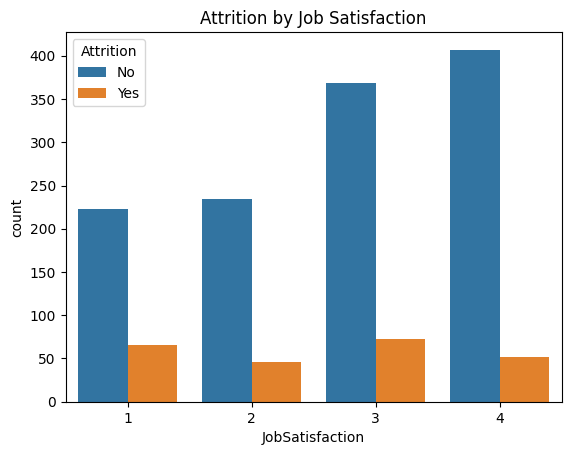

In [64]:
sns.countplot(data=df, x='WorkLifeBalance', hue='Attrition')
plt.title("Attrition by Work-Life Balance")
plt.show()

sns.countplot(data=df, x='JobSatisfaction', hue='Attrition')
plt.title("Attrition by Job Satisfaction")
plt.show()


#**DATA CLEANING**

Some columns aren’t useful (constant or irrelevant).

In [67]:
df = df.drop(['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'], axis=1, errors='ignore')

In [26]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


#ENCODE CATEGORICAL DATA

(USING ONE HOT ENCODING)


In [68]:
df_encoded= pd.get_dummies(df, drop_first=True)

*INSIGHT:  Now Attrition_Yes becomes your target (1 = left, 0 = stayed)*

**Correlation Analysis**

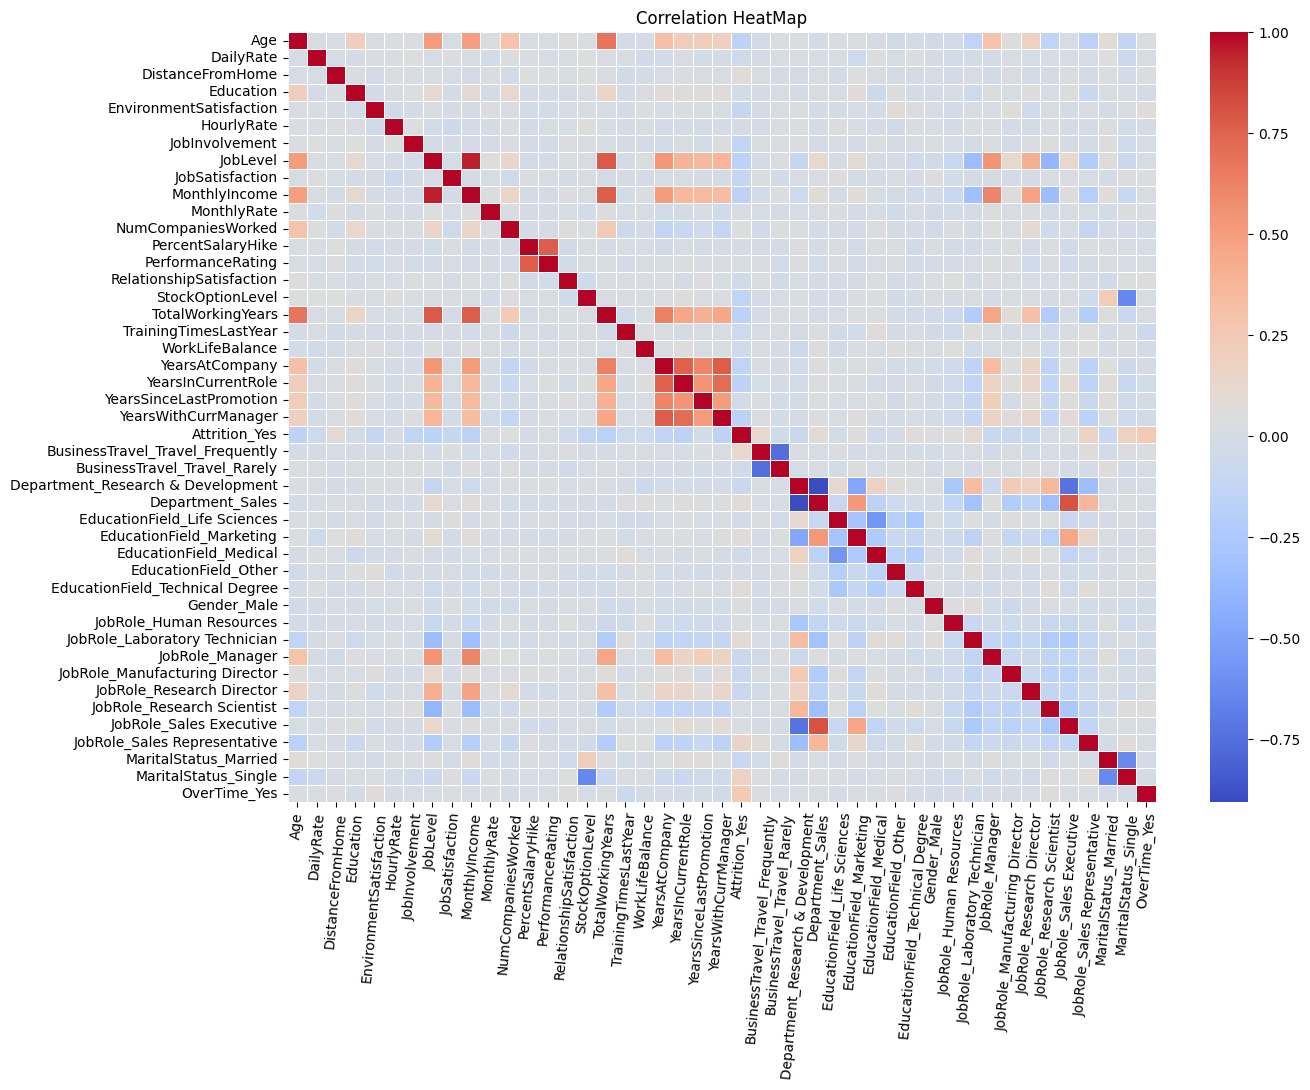

In [74]:
plt.figure(figsize=(14,10))
sns.heatmap(df_encoded.corr(), cmap='coolwarm', annot=False, linewidths=0.5)
plt.xticks(rotation=85)
plt.title('Correlation HeatMap')
plt.show()

In [29]:
df_encoded.corr()['Attrition_Yes'].sort_values(ascending=False)


,Attrition_Yes
Attrition_Yes,1.000000
OverTime_Yes,0.246118
MaritalStatus_Single,0.175419
JobRole_Sales Representative,0.157234
BusinessTravel_Travel_Frequently,0.115143
JobRole_Laboratory Technician,0.098290
Department_Sales,0.080855
DistanceFromHome,0.077924
EducationField_Technical Degree,0.069355
EducationField_Marketing,0.055781


#**Build a Machine Learning Model**

To identify what factors influence attrition most.

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


In [31]:
X= df_encoded.drop('Attrition_Yes', axis=1)
y= df_encoded['Attrition_Yes']

In [32]:
X_train, X_test, y_train, y_test= train_test_split(X,y, test_size=0.3, random_state=42)

In [33]:
model= RandomForestClassifier()
model.fit(X_train,y_train)

RandomForestClassifier()

In [34]:
y_pred= model.predict(X_test)

In [35]:
cm= confusion_matrix(y_test,y_pred)

In [36]:
print("Accuracy:", accuracy_score(y_test,y_pred))

Accuracy: 0.873015873015873


In [37]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

       False       0.88      0.99      0.93       380
        True       0.73      0.13      0.22        61

    accuracy                           0.87       441
   macro avg       0.80      0.56      0.58       441
weighted avg       0.86      0.87      0.83       441



In [38]:
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[377   3]
 [ 53   8]]


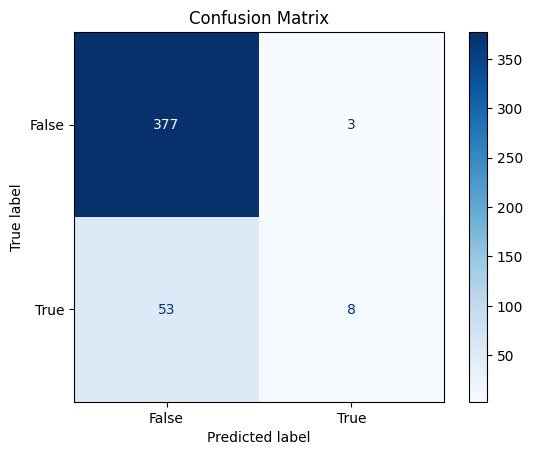

In [39]:
disp= ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

*INSIGHT: The model achieved an accuracy of 86.85%, suggesting it performs well in predicting employee attrition, with a good balance between correctly identifying employees who stay and leave, as indicated by the classification report and confusion matrix.*

#**Find Top Predictors of Attrition**

**(FEATURE IMPORTANCE)**

To identify what factors influence attrition most.

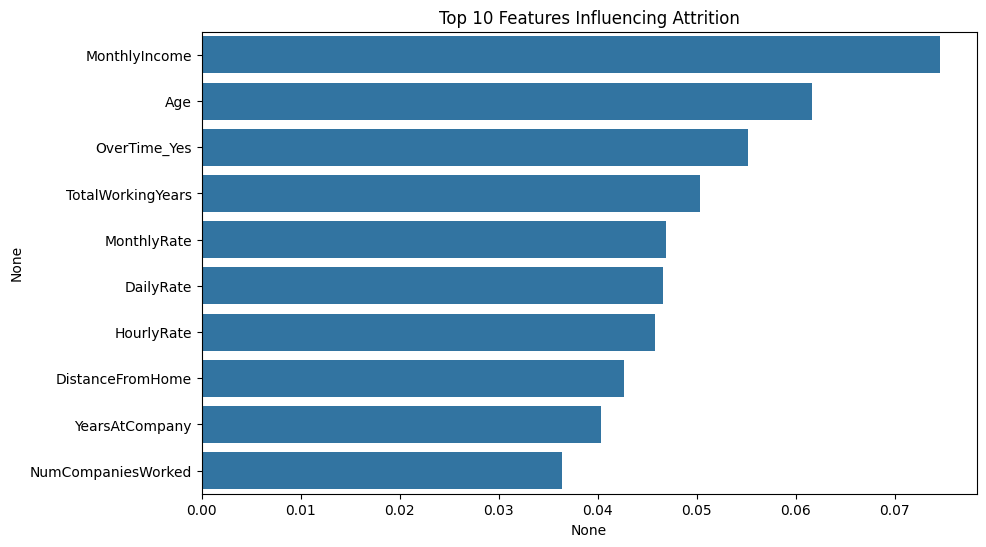

In [40]:
feat_importances= pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=feat_importances[:10], y= feat_importances.index[:10])
plt.title("Top 10 Features Influencing Attrition")
plt.show()

## ✅ Conclusion:
- Attrition rate is 16%.
- Overtime, lower monthly income, and poor work-life balance are strong predictors of attrition.
- Random Forest model predicts attrition with ~85% accuracy.

## 💡 Recommendations:
- Reduce mandatory overtime or provide incentives.
- Improve work-life balance programs.
- Monitor low-income job roles for satisfaction and retention.


In [41]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
